In [48]:
# IMPORT LIBRARIRES

# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# model preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# DIABETES PREDICTION

# 1. Problem Defination

To develop a machine learning model that accurately predicts the likelihood of a person developing diabetes based on various health indicators and demographic factors.


# 2. Data


In [49]:
df = pd.read_csv("data/diabetes_dataset.csv")
df.head() 

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [50]:
metadata = {
    'Feature': [        'year',         'gender',         'age',         'location',         'race:AfricanAmerican',         'race:Asian',         'race:Caucasian', 
        'race:Hispanic',         'race:Other',         'hypertension',         'heart_disease',         'smoking_history',         'bmi',         'hbA1c_level',         'blood_glucose_level',         'diabetes'    ],    'Description': [        'Year of data collection',        'Gender of the individual',        'Age of the individual',        'Geographic location of the individual',        'Indicates if the individual is African American',        'Indicates if the individual is Asian',        'Indicates if the individual is Caucasian',        'Indicates if the individual is Hispanic',        'Indicates if the individual belongs to another race',        'Indicates if the individual has hypertension',        'Indicates if the individual has heart disease',        'Indicates if the individual has a history of smoking',        'Body Mass Index of the individual',        'Hemoglobin A1c level of the individual (percentage)',        'Blood glucose level of the individual',        'Target variable indicating whether the individual has diabetes'    ],    'Data Type': [        'Integer',        'Categorical',        'Integer',        'Categorical',        'Binary',        'Binary',        'Binary',        'Binary',        'Binary',        'Binary',        'Binary',        'Binary',        'Float',        'Float',        'Float',        'Binary'    ],    'Possible Values': [        'e.g., 2023, 2024',        "'Male', 'Female'",        'e.g., 18, 45, 60',        "'Urban', 'Rural'",        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        '0 (No), 1 (Yes)',        'e.g., 22.5, 30.1',        'e.g., 5.5, 7.2',        'e.g., 85, 140',        '0 (No), 1 (Yes)'    ]
}

df_metadata = pd.DataFrame(metadata)
print("Data Dictionary")
df_metadata

Data Dictionary


,Feature,Description,Data Type,Possible Values
0,year,Year of data collection,Integer,"e.g., 2023, 2024"
1,gender,Gender of the individual,Categorical,"'Male', 'Female'"
2,age,Age of the individual,Integer,"e.g., 18, 45, 60"
3,location,Geographic location of the individual,Categorical,"'Urban', 'Rural'"
4,race:AfricanAmerican,Indicates if the individual is African American,Binary,"0 (No), 1 (Yes)"
5,race:Asian,Indicates if the individual is Asian,Binary,"0 (No), 1 (Yes)"
6,race:Caucasian,Indicates if the individual is Caucasian,Binary,"0 (No), 1 (Yes)"
7,race:Hispanic,Indicates if the individual is Hispanic,Binary,"0 (No), 1 (Yes)"
8,race:Other,Indicates if the individual belongs to another...,Binary,"0 (No), 1 (Yes)"
9,hypertension,Indicates if the individual has hypertension,Binary,"0 (No), 1 (Yes)"


# 3. Evaluation & 4. Features 

### EDA

In [51]:
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [52]:
df.shape

(100000, 16)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [54]:
df.isna().sum()

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [55]:
df["year"].value_counts()

year
2019    79745
2016     8760
2015     8760
2018     2678
2020       42
2022        8
2021        7
Name: count, dtype: int64

In [56]:
df["gender"].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [57]:
df["age"].value_counts()


age
80.00    5621
51.00    1619
47.00    1574
48.00    1568
53.00    1542
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64

In [58]:
df["location"].value_counts()

location
Kentucky                2038
Iowa                    2038
Hawaii                  2038
Nebraska                2038
Florida                 2037
Minnesota               2037
Arkansas                2037
New Jersey              2037
Massachusetts           2036
Kansas                  2036
Louisiana               2036
District of Columbia    2036
Maine                   2036
Delaware                2036
Georgia                 2036
Michigan                2036
Illinois                2036
Pennsylvania            2036
Oregon                  2036
Alabama                 2036
Connecticut             2035
Maryland                2035
Alaska                  2035
North Dakota            2035
New York                2035
North Carolina          2035
Mississippi             2035
Rhode Island            2035
Colorado                2035
Missouri                2035
New Hampshire           2035
New Mexico              2033
South Dakota            2033
Montana                 2033
Idaho

In [59]:
df["smoking_history"].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [60]:
df.dtypes

year                      int64
gender                   object
age                     float64
location                 object
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history          object
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
dtype: object

In [61]:
### visualization

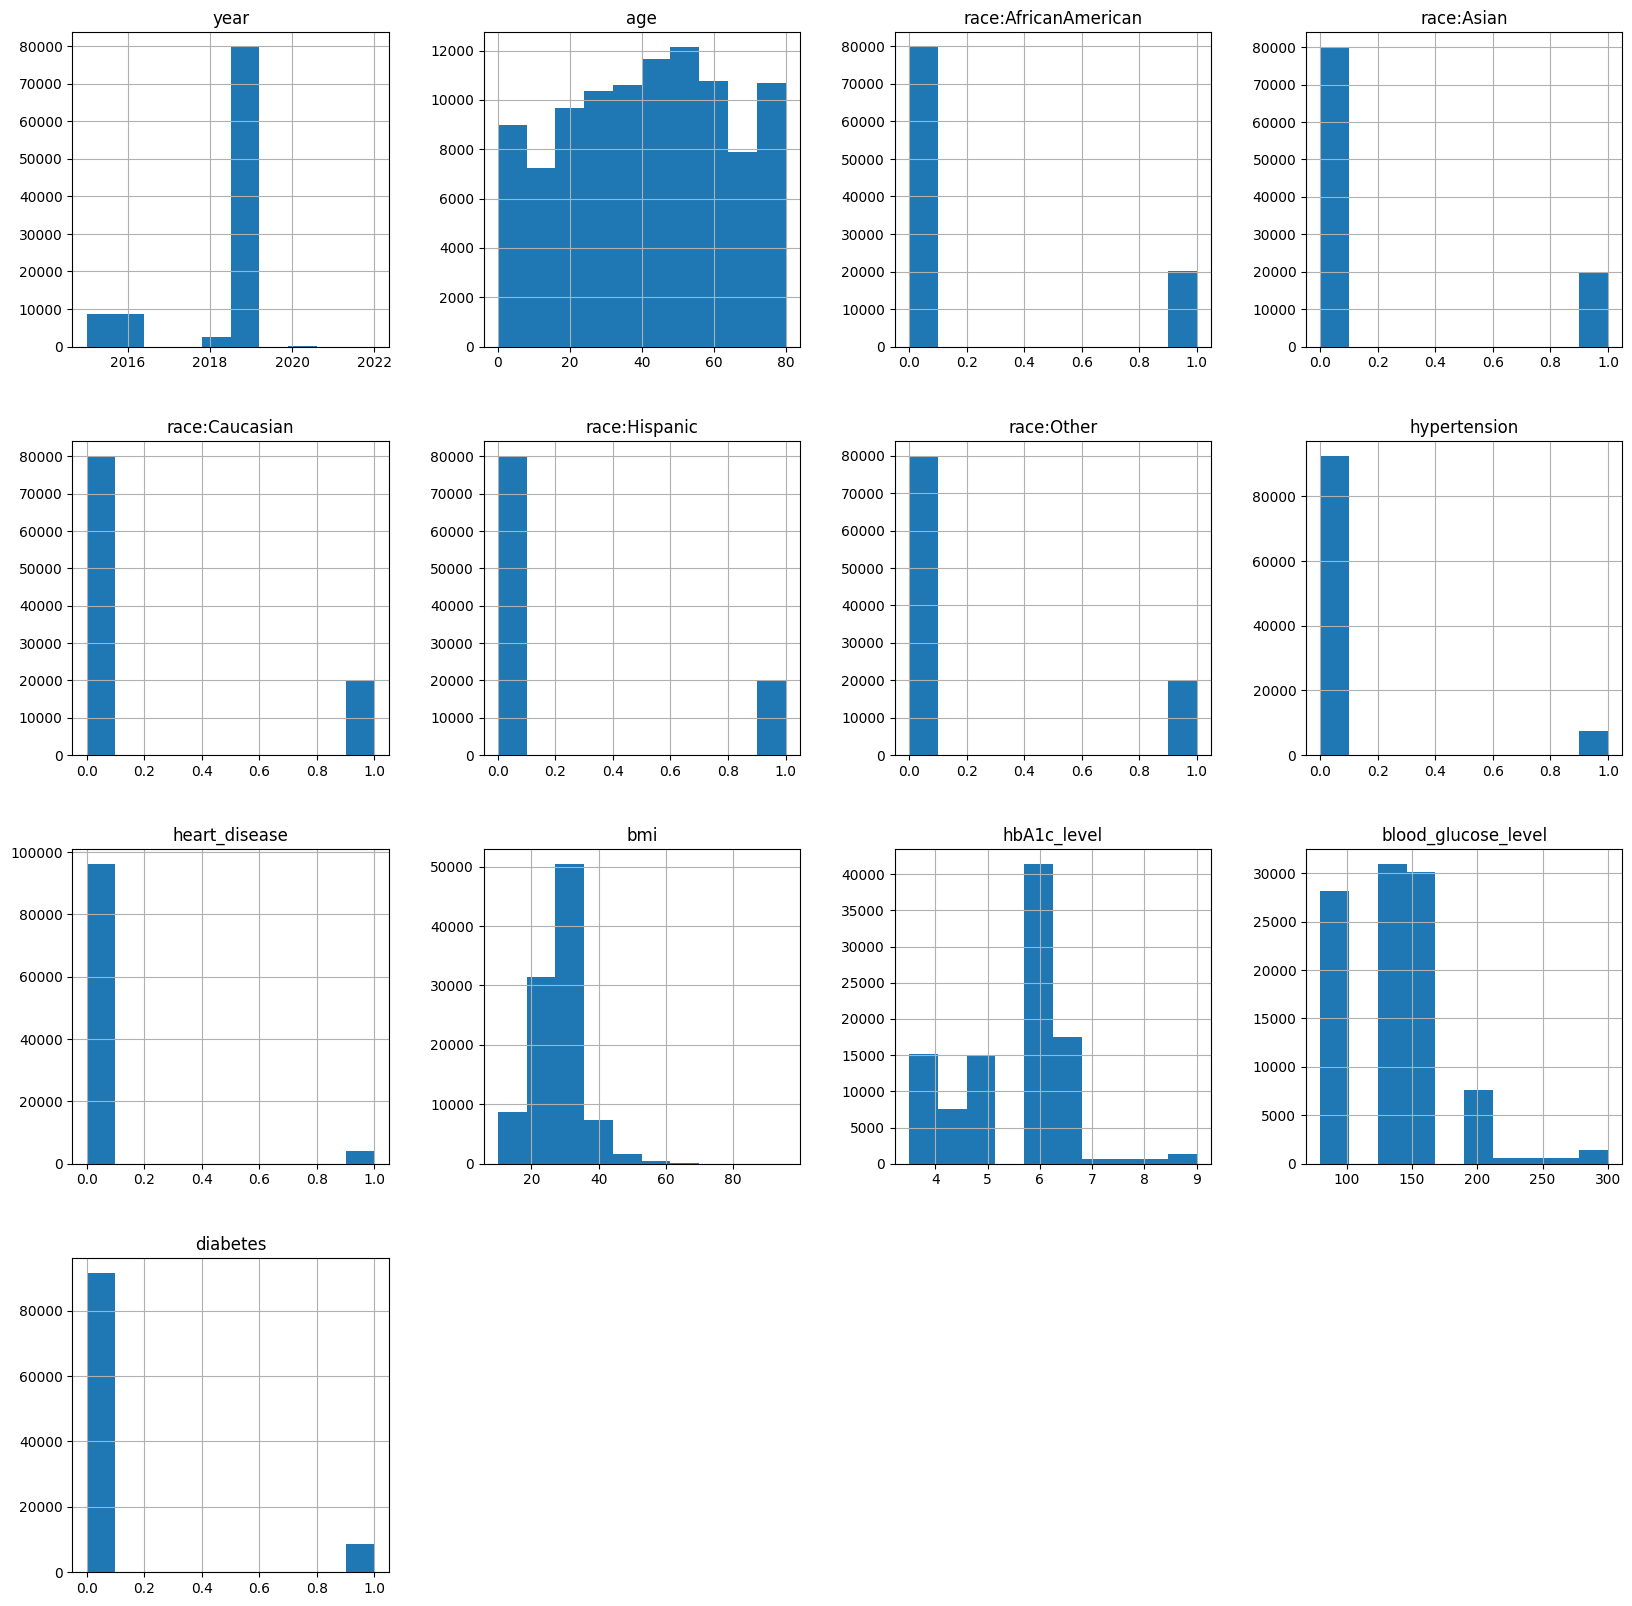

In [62]:
df.hist(figsize=(20,20),bins=10)
plt.savefig("images/histograms.png")

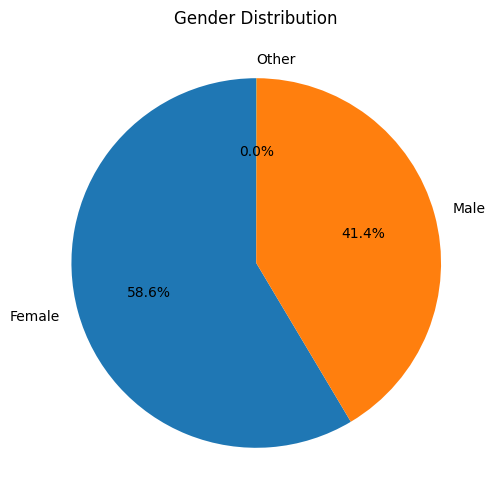

In [63]:
fig=plt.figure(figsize=(10,6))
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.1f%%',startangle=90)
plt.title('Gender Distribution')

plt.savefig("Gender Distribution.png")
plt.show()

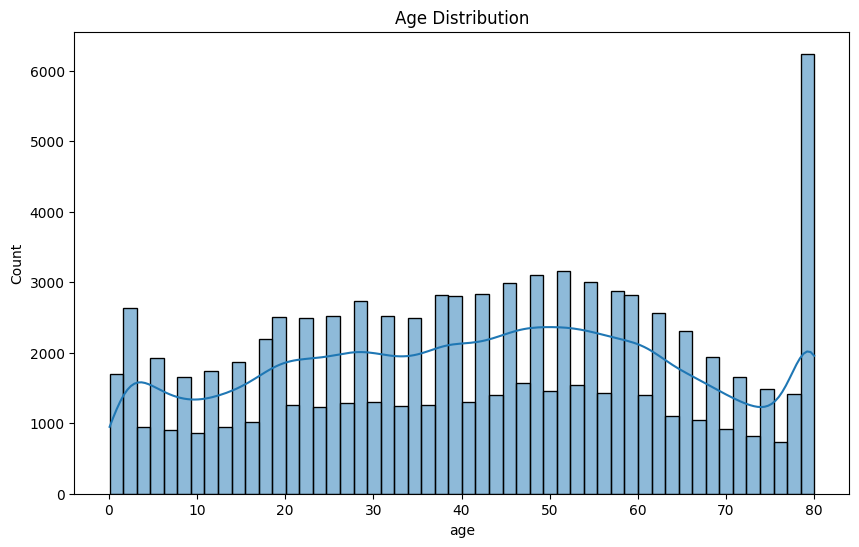

In [64]:
fig=plt.figure(figsize=(10,6))
sns.histplot(df['age'],kde=True)
plt.title('Age Distribution')
plt.savefig("images/Age Distribution.png")
plt.show()

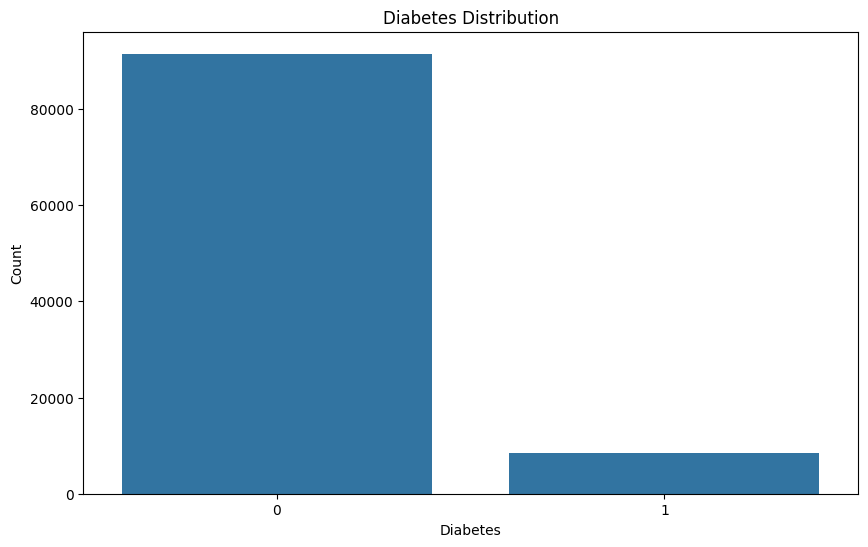

In [65]:
fig = plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='diabetes')
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

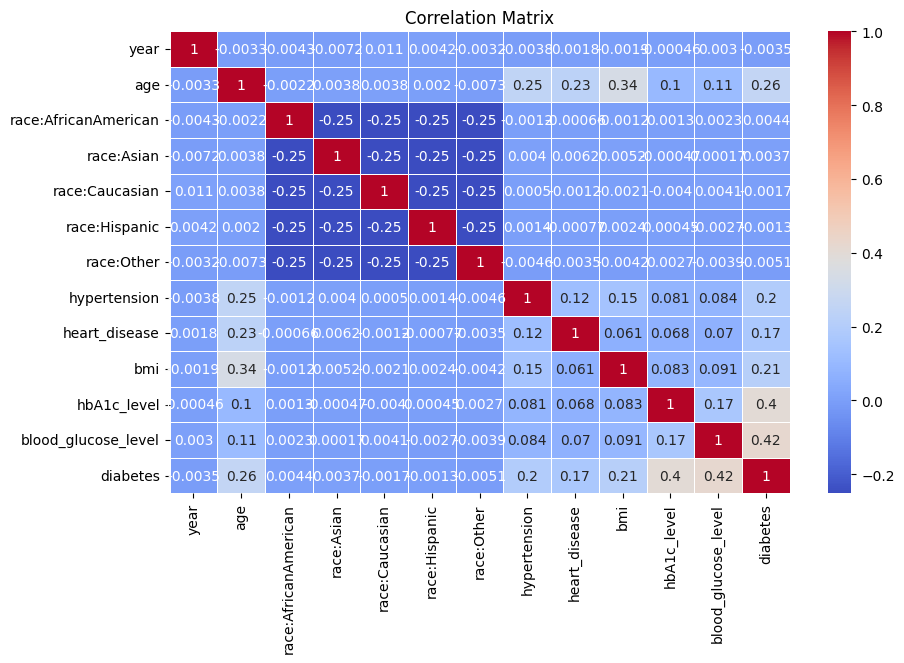

In [66]:
numeric_df=df.select_dtypes(include=[np.number])
fig=plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# 5. Modeling

### EDA

In [67]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['location']=le.fit_transform(df['location'])
df['smoking_history']=le.fit_transform(df['smoking_history'])

In [68]:
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,0,32.0,0,0,0,0,0,1,0,0,4,27.32,5.0,100,0
1,2015,0,29.0,0,0,1,0,0,0,0,0,4,19.95,5.0,90,0
2,2015,1,18.0,0,0,0,0,0,1,0,0,4,23.76,4.8,160,0
3,2015,1,41.0,0,0,0,1,0,0,0,0,4,27.32,4.0,159,0
4,2016,0,52.0,0,1,0,0,0,0,0,0,4,23.75,6.5,90,0


In [69]:
df.rename(columns={'race:AfricanAmerican': 'africanamerican'}, inplace=True)
df.rename(columns={'race:Caucasian': 'caucasian'}, inplace=True)
df.rename(columns={'race:Hispanic': 'hispanic'}, inplace=True)
df.rename(columns={'race:Asian': 'asian'}, inplace=True)
df.rename(columns={'race:Other': 'other'}, inplace=True)

In [70]:
x=df.drop('diabetes',axis=1)
y=df['diabetes']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

### Find best model

In [71]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
   # 'SVM': SVC()
}

In [72]:
# Dictionary to store the accuracy of each model
model_accuracies = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(xtrain, ytrain)
    y_pred = model.predict(xtest)
    accuracy = accuracy_score(ytest, y_pred)
    model_accuracies[name] = accuracy
    print(f'{name} Accuracy: {accuracy:.4f}')

# Find the model with the best accuracy
best_model = max(model_accuracies, key=model_accuracies.get)
print(f'Best Model: {best_model} with Accuracy: {model_accuracies[best_model]:.4f}')

Decision Tree Accuracy: 0.9502
Random Forest Accuracy: 0.9718
Best Model: Random Forest with Accuracy: 0.9718


### using the best model

In [73]:
# Initialize the RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(xtrain, ytrain)
y_pred = rf.predict(xtest)
accuracy = accuracy_score(ytest, y_pred)
print(f'{name} Accuracy: {accuracy:.4f}')

Random Forest Accuracy: 0.9721


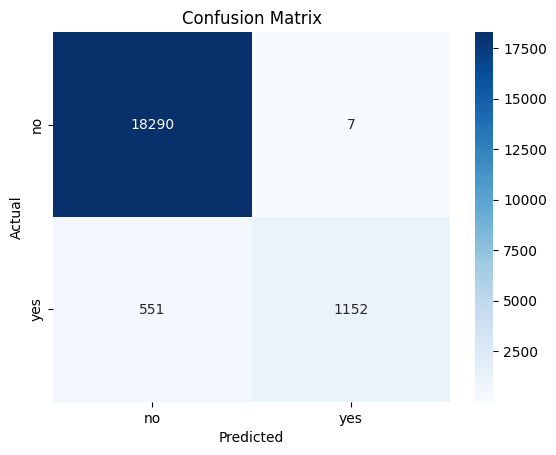

In [74]:
cm = confusion_matrix(ytest, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['no', 'yes'], 
            yticklabels=['no', 'yes'])  
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### param tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Example parameter grid to tune
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30],        # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],    # Minimum number of samples required at each leaf node
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier()

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=2, n_jobs=-1, verbose=2)

# Fit the model with the training data
grid_search.fit(xtrain, ytrain)

# Get the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate on the test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(xtest)
accuracy = accuracy_score(ytest, y_pred)
print(f"Accuracy with Best Hyperparameters: {accuracy:.4f}")


Fitting 2 folds for each of 162 candidates, totalling 324 fits


In [ ]:
model = RandomForestClassifier(
    bootstrap=False,
    max_depth=20,
    min_samples_leaf=4,
    min_samples_split=5,
    n_estimators=200
)

In [ ]:
model.fit(xtrain, ytrain)

ypred = model.predict(xtest)

cm = confusion_matrix(ytest, ypred)

accuracy = accuracy_score(ytest, ypred)
print(f"Accuracy with Best Hyperparameters: {accuracy:.4f}")

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no', 'yes'],
            yticklabels=['no', 'yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
report = classification_report(ytest, ypred)
print(report)